In [1]:
import sympy as sp

# -----------------------------
# 1. 좌표와 함수 정의
# -----------------------------
t, r, th, ph = sp.symbols('t r theta phi', real=True)
k = sp.symbols('k', real=True)
a = sp.Function('a')(t)

coords = [t, r, th, ph]
n = len(coords)

# -----------------------------
# 2. FRW metric (signature: +,-,-,-)
#    ds^2 = dt^2 - a(t)^2 [dr^2/(1-k r^2) + r^2 dθ^2 + r^2 sin^2θ dφ^2]
# -----------------------------
g = sp.Matrix([
    [1, 0, 0, 0],
    [0, -a**2/(1-k*r**2), 0, 0],
    [0, 0, -a**2*r**2, 0],
    [0, 0, 0, -a**2*r**2*sp.sin(th)**2]
])

g_inv = sp.simplify(g.inv())

# -----------------------------
# 3. Christoffel symbol
#    Γ^μ_{νρ} = 1/2 g^{μσ}(∂_ν g_{σρ} + ∂_ρ g_{σν} - ∂_σ g_{νρ})
# -----------------------------
Gamma = [[[0 for _ in range(n)] for _ in range(n)] for _ in range(n)]

for mu in range(n):
    for nu in range(n):
        for rho in range(n):
            expr = 0
            for sigma in range(n):
                expr += g_inv[mu, sigma] * (
                    sp.diff(g[sigma, rho], coords[nu]) +
                    sp.diff(g[sigma, nu], coords[rho]) -
                    sp.diff(g[nu, rho], coords[sigma])
                )
            Gamma[mu][nu][rho] = sp.simplify(sp.Rational(1, 2) * expr)

# -----------------------------
# 4. Ricci tensor
#    R_{μν} = ∂_ρ Γ^ρ_{μν} - ∂_ν Γ^ρ_{μρ}
#             + Γ^ρ_{ρλ}Γ^λ_{μν} - Γ^ρ_{νλ}Γ^λ_{μρ}
# -----------------------------
Ricci = sp.Matrix.zeros(n, n)

for mu in range(n):
    for nu in range(n):
        expr = 0
        for rho in range(n):
            expr += sp.diff(Gamma[rho][mu][nu], coords[rho])
            expr -= sp.diff(Gamma[rho][mu][rho], coords[nu])

            for lam in range(n):
                expr += Gamma[rho][rho][lam] * Gamma[lam][mu][nu]
                expr -= Gamma[rho][nu][lam] * Gamma[lam][mu][rho]

        Ricci[mu, nu] = sp.simplify(sp.trigsimp(expr))

# -----------------------------
# 5. Ricci scalar
#    R = g^{μν} R_{μν}
# -----------------------------
R_scalar = 0
for mu in range(n):
    for nu in range(n):
        R_scalar += g_inv[mu, nu] * Ricci[mu, nu]

R_scalar = sp.simplify(sp.trigsimp(R_scalar))

# -----------------------------
# 6. 0이 아닌 Christoffel symbol 출력
# -----------------------------
print("\n=== Nonzero Christoffel symbols ===")
for mu in range(n):
    for nu in range(n):
        for rho in range(n):
            val = sp.simplify(Gamma[mu][nu][rho])
            if val != 0:
                print(f"Gamma^{mu}_{nu}{rho} =", val)

# -----------------------------
# 7. Ricci tensor 출력
# -----------------------------
print("\n=== Ricci tensor R_{mu nu} ===")
for mu in range(n):
    for nu in range(n):
        val = sp.simplify(Ricci[mu, nu])
        if val != 0:
            print(f"R_{mu}{nu} =", val)

# -----------------------------
# 8. Ricci scalar 출력
# -----------------------------
print("\n=== Ricci scalar R ===")
print(R_scalar)


=== Nonzero Christoffel symbols ===
Gamma^0_11 = -a(t)*Derivative(a(t), t)/(k*r**2 - 1)
Gamma^0_22 = r**2*a(t)*Derivative(a(t), t)
Gamma^0_33 = r**2*a(t)*sin(theta)**2*Derivative(a(t), t)
Gamma^1_01 = Derivative(a(t), t)/a(t)
Gamma^1_10 = Derivative(a(t), t)/a(t)
Gamma^1_11 = -k*r/(k*r**2 - 1)
Gamma^1_22 = k*r**3 - r
Gamma^1_33 = r*(k*r**2 - 1)*sin(theta)**2
Gamma^2_02 = Derivative(a(t), t)/a(t)
Gamma^2_12 = 1/r
Gamma^2_20 = Derivative(a(t), t)/a(t)
Gamma^2_21 = 1/r
Gamma^2_33 = -sin(2*theta)/2
Gamma^3_03 = Derivative(a(t), t)/a(t)
Gamma^3_13 = 1/r
Gamma^3_23 = 1/tan(theta)
Gamma^3_30 = Derivative(a(t), t)/a(t)
Gamma^3_31 = 1/r
Gamma^3_32 = 1/tan(theta)

=== Ricci tensor R_{mu nu} ===
R_00 = -3*Derivative(a(t), (t, 2))/a(t)
R_11 = (-2*k - a(t)*Derivative(a(t), (t, 2)) - 2*Derivative(a(t), t)**2)/(k*r**2 - 1)
R_22 = r**2*(2*k + a(t)*Derivative(a(t), (t, 2)) + 2*Derivative(a(t), t)**2)
R_33 = r**2*(2*k + a(t)*Derivative(a(t), (t, 2)) + 2*Derivative(a(t), t)**2)*sin(theta)**2

=== Ricci 

In [1]:
from sympy import *
from sympy.matrices import Matrix, zeros
from sympy import symbols
from sympy import Function, Symbol, Derivative
from IPython.display import display, Latex
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
init_printing(use_unicode=True)

In [2]:
orientationError = 'ERROR: Please enter either "down" or "up" for the orientation of your metric'
indexError = 'ERROR: Please ensure your index values are integers between 0 and 3'

#Function to compute all Christoffel symbols
def ChristoffelSymbols(metricpack):
    
    g, sym, orientation = metricpack
    
    if (orientation != "down" and orientation != "up"):
        #Ensuring the correct orientation values are inputted
        print(orientationError)
    
    else:
        #Having the right metric components corresponding to the upstairs or downstairs metric
        if (orientation == "down"):
            gdndn = g
            gupup = gdndn.inv()
        else:
            gupup = g
            gdndn = gupup.inv()

        #Creating matrix for variables
        dava = Matrix(sym)

        #Creating empty Gamma matrix
        Gamma = Matrix([[[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]],
                              [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]],
                              [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]],
                              [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]]])
        #Compute Christoffels
        for s in range(4):
            for m in range(4):
                for n in range(4):
                    for l in range(4):
                        Gamma[(m,n)][l] += simplify(((1/2)*gupup[(m,s)])*((diff(gdndn[(s,l)],dava[n])) 
                                              + (diff(gdndn[(n,s)],dava[l])) 
                                              - (diff(gdndn[(n,l)],dava[s]))))
        return Gamma
    

#If we just need a specific Christoffel symbol
def GiveChristoffel(mu,nu,lamb,metricpack):
    
    g, sym, orientation = metricpack
    
    if (orientation != "down" and orientation != "up"):
        #Ensuring the correct orientation values are inputted
        print(orientationError)
    else:
        if (isinstance(mu, int) and isinstance(nu, int) and isinstance(lamb, int) and mu < 4 and mu >=0 and nu < 4 and nu >=0 and lamb < 4 and lamb >=0):
            chris = ChristoffelSymbols(metricpack)
            return chris[(mu,nu)][lamb]
        else:
            print(indexError)
    

#Computing all Reimann Tensors
def ReimannTensor(metricpack):
    
    g, sym, orientation = metricpack
    
    if (orientation != "down" and orientation != "up"):
        #Ensuring the correct orientation values are inputted
        print(orientationError)
    
    else:
        #Christoffels
        Gamma = ChristoffelSymbols(metricpack)

        #Creating matrix for variables
        dava = Matrix(sym)

        #Empty Reimann Matrix
        Reimann = Matrix([[[[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]],
                            [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]],
                            [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]],
                            [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]]],
                           [[[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]],
                            [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]],
                            [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]],
                            [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]]],
                           [[[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]],
                            [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]],
                            [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]],
                            [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]]],
                           [[[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]],
                            [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]],
                            [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]],
                            [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]]]])

        #Computing the Reimanns
        for p in range(4):
            for s in range(4):
                for m in range(4):
                    for n in range(4):
                        Reimann[(p,s)][m][n] = simplify((diff(Gamma[(p,s)][n],dava[m]) - diff(Gamma[(p,s)][m],dava[n])))
        l = 0
        p = 0
        s = 0
        m = 0
        n = 0

        for l in range(4):
            for p in range(4):
                for s in range(4):
                    for m in range(4):
                        for n in range(4):
                            Reimann[(p,s)][m][n] += simplify((Gamma[(l,s)][n]*Gamma[(p,l)][m] - Gamma[(l,s)][m]*Gamma[(p,l)][n]))

        return Reimann
    

#If we just need a specific Reimann tensor
def GiveReimann(pho,sigma,mu,nu,metricpack):
    
    g, sym, orientation = metricpack
    
    if (orientation != "down" and orientation != "up"):
        #Ensuring the correct orientation values are inputted
        print(orientationError)
        
    else:
        if (isinstance(mu, int) and isinstance(nu, int) and isinstance(pho, int) and isinstance(sigma, int) and mu < 4 and mu >=0 and nu < 4 and nu >=0 and sigma < 4 and sigma >=0 and pho < 4 and pho >= 0):
            rem = ReimannTensor(metricpack)
            return rem[(pho,sigma)][mu][nu]
        else:
            print(indexError)
    

#Compute Ricci Tensor
def RicciTensor(metricpack):
    
    g, sym, orientation = metricpack
    
    if (orientation != "down" and orientation != "up"):
        #Ensuring the correct orientation values are inputted
        print(orientationError)
        
    else:
        remm = ReimannTensor(metricpack)
        
        Ricci = Matrix([[0,0,0,0],[0,0,0,0],
                        [0,0,0,0],[0,0,0,0]])
        
        for x in range(4):
            for y in range(4):
                for z in range(4):
                    Ricci[y,z] += simplify(remm[x,y][z][x])
                    
        return Ricci

#If we just need a specific Ricci
def GiveRicci(mu,nu,metricpack):
    
    g, sym, orientation = metricpack
    
    if (orientation != "down" and orientation != "up"):
        #Ensuring the correct orientation values are inputted
        print(orientationError)
    
    else:
        ricci = RicciTensor(metricpack)
        return simplify(ricci[mu,nu])

#To compute Ricci Scalar
def RicciScalar(metricpack):
    
    g, sym, orientation = metricpack
    
    if (orientation != "down" and orientation != "up"):
        #Ensuring the correct orientation values are inputted
        print(orientationError)
        
    else:
        #Having the right metric components corresponding to the upstairs or downstairs metric
        if (orientation == "down"):
            gdndn = g
            gupup = gdndn.inv()
        else:
            gupup = g
            
        ricciscalare = 0
        
        ricciten = RicciTensor(metricpack)
        
        for i in range(4):
            ricciscalare += gupup[i,i]*ricciten[i,i]
            
        return simplify(ricciscalare)

In [15]:
t, r, th, ph = symbols('t r h p') #Edit symbols here
variables = [t,r,th,ph] #Edit symbols here
k = symbols('k', real=True)
a = Function('a')(t)

gtensor = Matrix([
    [1, 0, 0, 0],
    [0, -a**2/(1-k*r**2), 0, 0],
    [0, 0, -a**2*r**2, 0],
    [0, 0, 0, -a**2*r**2*sin(th)**2]
])

orientation = "down" #Orientation of the gtensor, whether it is g_mu_nu ("down") or g^mu^nu ("up")

metric = [gtensor,variables,orientation] #List of the gtensor, variables and orientation to be used

In [16]:
#Display a matrix of all possible Christoffel Symbols:
ChristoffelSymbols(metric)

⎡                         ⎡             d              ⎤                       ↪
⎢                         ⎢   -1.0⋅a(t)⋅──(a(t))       ⎥                       ↪
⎢                         ⎢             dt             ⎥   ⎡           2       ↪
⎢     [0, 0, 0, 0]        ⎢0, ───────────────────, 0, 0⎥   ⎢0, 0, 1.0⋅r ⋅a(t)⋅ ↪
⎢                         ⎢           2                ⎥   ⎣                   ↪
⎢                         ⎣        k⋅r  - 1            ⎦                       ↪
⎢                                                                              ↪
⎢⎡       d             ⎤  ⎡    d                        ⎤                      ↪
⎢⎢   1.0⋅──(a(t))      ⎥  ⎢1.0⋅──(a(t))                 ⎥                      ↪
⎢⎢       dt            ⎥  ⎢    dt        -1.0⋅k⋅r       ⎥    ⎡            ⎛    ↪
⎢⎢0, ────────────, 0, 0⎥  ⎢────────────, ─────────, 0, 0⎥    ⎣0, 0, 1.0⋅r⋅⎝k⋅r ↪
⎢⎣       a(t)          ⎦  ⎢    a(t)         2           ⎥                      ↪
⎢                         ⎣ 

In [ ]:
#Display a matrix of all possible Christoffel Symbols:
ChristoffelSymbols(metric)

⎡                         ⎡             d              ⎤                       ↪
⎢                         ⎢   -1.0⋅a(t)⋅──(a(t))       ⎥                       ↪
⎢                         ⎢             dt             ⎥   ⎡           2       ↪
⎢     [0, 0, 0, 0]        ⎢0, ───────────────────, 0, 0⎥   ⎢0, 0, 1.0⋅r ⋅a(t)⋅ ↪
⎢                         ⎢           2                ⎥   ⎣                   ↪
⎢                         ⎣        k⋅r  - 1            ⎦                       ↪
⎢                                                                              ↪
⎢⎡       d             ⎤  ⎡    d                        ⎤                      ↪
⎢⎢   1.0⋅──(a(t))      ⎥  ⎢1.0⋅──(a(t))                 ⎥                      ↪
⎢⎢       dt            ⎥  ⎢    dt        -1.0⋅k⋅r       ⎥    ⎡            ⎛    ↪
⎢⎢0, ────────────, 0, 0⎥  ⎢────────────, ─────────, 0, 0⎥    ⎣0, 0, 1.0⋅r⋅⎝k⋅r ↪
⎢⎣       a(t)          ⎦  ⎢    a(t)         2           ⎥                      ↪
⎢                         ⎣ 

In [17]:
#Display the Reimann Tensor:
ReimannTensor(metric)

⎡                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                    [[0, 0, 0, 0], [0, 0, 0,  ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢⎡⎡       ⎛      2                    2⎞                        ⎤  ⎡    ⎛      ↪
⎢⎢⎢       ⎜     d           ⎛d       ⎞ ⎟                 2      ⎥  ⎢    ⎜      ↪
⎢⎢⎢   1.0⋅⎜a(t)⋅───(a(t)) - ⎜──(a(t))⎟ ⎟       ⎛d       ⎞       ⎥  ⎢1.0⋅⎜- a(t ↪
⎢⎢⎢       ⎜       2         

In [18]:
#Display the Ricci Tensor:
RicciTensor(metric)

⎡     2                                                                        ↪
⎢    d                                                                         ↪
⎢3.0⋅───(a(t))                                                                 ↪
⎢      2                                                                       ↪
⎢    dt                                                                        ↪
⎢─────────────                      0                                          ↪
⎢    a(t)                                                                      ↪
⎢                                                                              ↪
⎢                                                 2                            ↪
⎢                   ⎛              2⎞            d                             ↪
⎢                   ⎜    ⎛d       ⎞ ⎟   1.0⋅a(t)⋅───(a(t))                     ↪
⎢               2.0⋅⎜k + ⎜──(a(t))⎟ ⎟              2                           ↪
⎢                   ⎝    ⎝dt

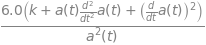

In [19]:
#Display the Ricci Scalar:
RicciScalar(metric)